# Real Hopf Fibration (S⁰ → S¹ → S¹) Validation

**Purpose**: Validate the simplest Hopf fibration — a double-covering map
that decomposes unit circle elements into a base angle and a discrete sign.

## The Real Hopf Map

For $z = (\cos\alpha, \sin\alpha) \in S^1$:
- **Base**: $\theta = 2\alpha \mod 2\pi$ (double-covering angle)
- **Fiber**: $s = \text{sign}(\cos\alpha) \in \{-1, +1\}$ (hemisphere)

Key property: $z$ and $-z$ map to the **same** base but **opposite** fibers.

In [1]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt

from hopf_layers import RealHopfLayer

from results_utils import setup_results, save_figure, save_table, save_data

RESULTS = setup_results("02_real_hopf_validation")

# Device setup for GPU support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

layer = RealHopfLayer().to(device)
print("RealHopfLayer loaded")

Results dir: C:\Users\ugure\ccode\categorical-tqft-emergence\hopf-layers\notebooks\results\02_real_hopf_validation
  figures/  tables/  data/
Device: cpu
RealHopfLayer loaded


## 1. Double Covering Visualization

  Saved: 02_real_hopf_validation\figures\double_covering_visualization.pdf


  Saved: 02_real_hopf_validation\figures\double_covering_visualization.png


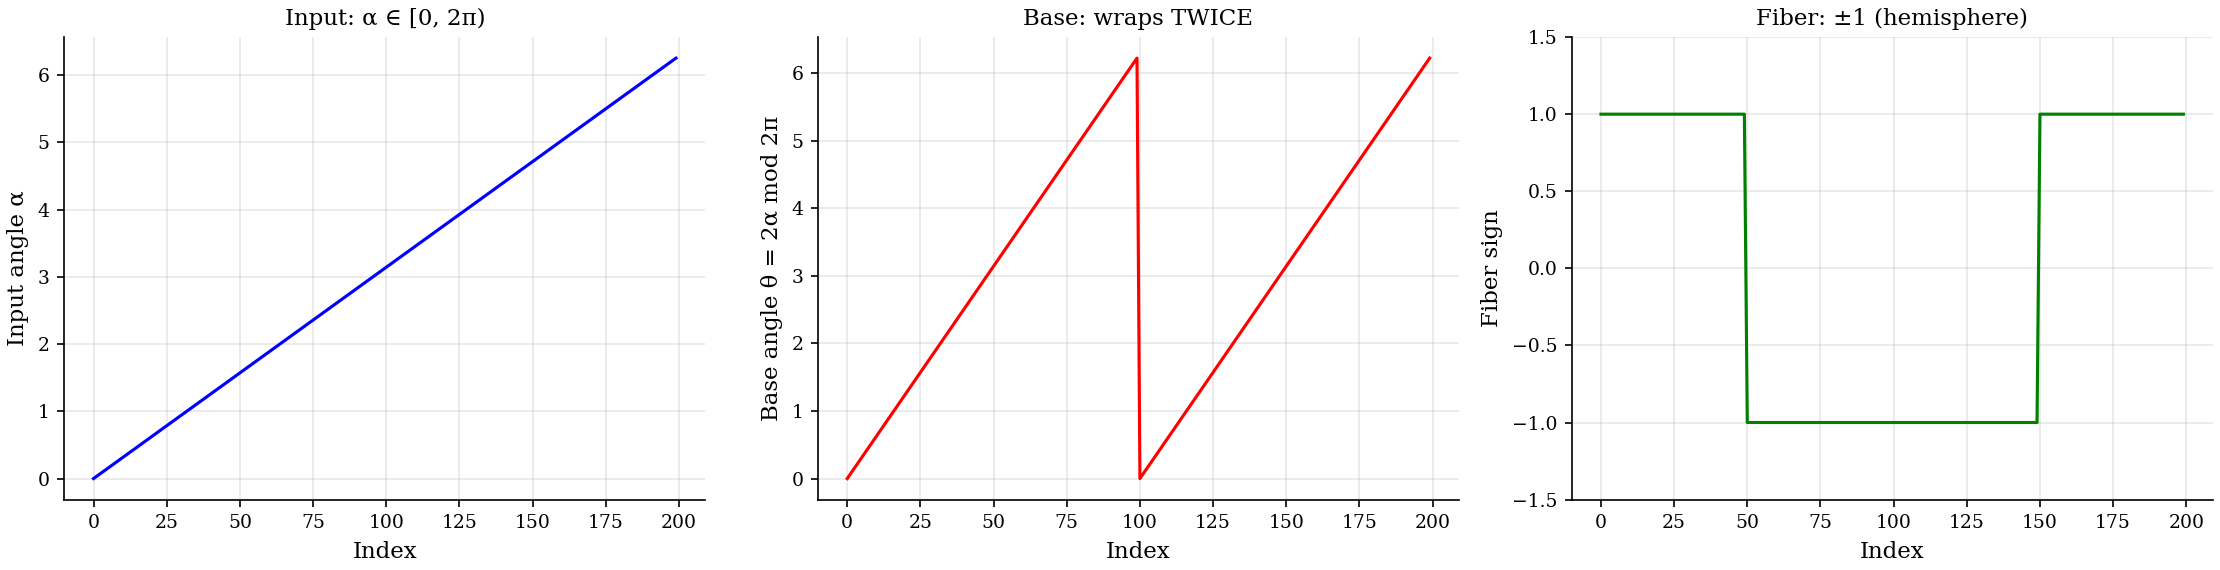

In [2]:
# Sample points around S^1
n = 200
alpha = torch.linspace(0, 2 * math.pi, n + 1, device=device)[:-1]
z = torch.stack([torch.cos(alpha), torch.sin(alpha)], dim=-1)
out = layer(z)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Input angle
axes[0].plot(alpha.cpu().numpy(), 'b-', linewidth=1.5)
axes[0].set_ylabel('Input angle α')
axes[0].set_xlabel('Index')
axes[0].set_title('Input: α ∈ [0, 2π)')

# Base angle (double cover)
axes[1].plot(out.base.cpu().numpy(), 'r-', linewidth=1.5)
axes[1].set_ylabel('Base angle θ = 2α mod 2π')
axes[1].set_xlabel('Index')
axes[1].set_title('Base: wraps TWICE')

# Fiber (discrete sign)
axes[2].plot(out.fiber.cpu().numpy(), 'g-', linewidth=1.5)
axes[2].set_ylabel('Fiber sign')
axes[2].set_xlabel('Index')
axes[2].set_title('Fiber: ±1 (hemisphere)')
axes[2].set_ylim(-1.5, 1.5)

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
save_figure(fig, "double_covering_visualization", RESULTS)
plt.show()

## 2. Validation Gates

In [3]:
# Gate 1: S^1 constraint — base is in [0, 2pi)
print("GATE 1: Base range")
assert out.base.min() >= 0.0
assert out.base.max() < 2 * math.pi + 1e-6
print(f"  base ∈ [{out.base.min():.4f}, {out.base.max():.4f}]  [PASS]")

# Gate 2: Fiber is discrete {-1, +1}
print("\nGATE 2: Discrete fiber")
assert ((out.fiber == 1.0) | (out.fiber == -1.0)).all()
print(f"  All values in {{-1, +1}}  [PASS]")

# Gate 3: Double covering — z and -z give same base
print("\nGATE 3: Double covering") 
out_neg = layer(-z)
base_diff = torch.remainder(out.base - out_neg.base, 2 * math.pi)
base_diff = torch.min(base_diff, 2 * math.pi - base_diff)
max_diff = base_diff.max().item()
assert max_diff < 1e-5
print(f"  max |base(z) - base(-z)| = {max_diff:.2e}  [PASS]")

# Gate 4: Round-trip reconstruction
# Use random unit vectors to avoid the measure-zero boundary at x=0,
# where the discrete fiber assignment is ambiguous (cos(alpha) ≈ 0).
print("\nGATE 4: Reconstruction round-trip")
torch.manual_seed(42)
z_rt = torch.randn(200, 2, device=device)
z_rt = z_rt / z_rt.norm(dim=-1, keepdim=True)
out_rt = layer(z_rt)
z_rec = layer.inverse(out_rt.base, out_rt.fiber)
rec_err = (z_rec - z_rt).abs().max().item()
assert rec_err < 1e-5, f"Reconstruction error {rec_err:.2e} exceeds 1e-5"
print(f"  max |z_rec - z| = {rec_err:.2e}  [PASS]")

# Gate 5: Gradient flow
print("\nGATE 5: Gradient flow")
z_g = torch.randn(16, 2, requires_grad=True, device=device)
out_g = layer(z_g)
out_g.base.sum().backward()
assert z_g.grad is not None and not torch.isnan(z_g.grad).any()
print(f"  Gradients: finite, non-NaN  [PASS]")

print("\n>>> All gates PASSED <<<")

# Save validation results
save_table(
    {
        "Gate": ["1", "2", "3", "4", "5"],
        "Test": ["Base range", "Discrete fiber", "Double covering", "Reconstruction", "Gradient flow"],
        "Criterion": [
            "base in [0, 2pi)",
            "fiber in {-1, +1}",
            "|base(z) - base(-z)| < 1e-5",
            "|z_rec - z| < 1e-5",
            "Finite non-NaN gradients",
        ],
        "Status": ["PASS"] * 5,
    },
    "real_hopf_gates",
    RESULTS,
    caption="Real Hopf fibration validation gates",
    label="tab:real-hopf-gates",
)
save_data(
    {
        "base_min": [out.base.min().item()],
        "base_max": [out.base.max().item()],
        "double_cover_max_diff": [max_diff],
        "reconstruction_max_err": [rec_err],
    },
    "gate_measurements",
    RESULTS,
)
print("\nAll results saved to:", RESULTS)

GATE 1: Base range
  base ∈ [0.0000, 6.2204]  [PASS]

GATE 2: Discrete fiber
  All values in {-1, +1}  [PASS]

GATE 3: Double covering
  max |base(z) - base(-z)| = 4.77e-07  [PASS]

GATE 4: Reconstruction round-trip
  max |z_rec - z| = 4.17e-07  [PASS]

GATE 5: Gradient flow
  Gradients: finite, non-NaN  [PASS]

>>> All gates PASSED <<<
  Saved: 02_real_hopf_validation\tables\real_hopf_gates.csv
  Saved: 02_real_hopf_validation\tables\real_hopf_gates.tex
  Saved: 02_real_hopf_validation\data\gate_measurements.json
  Saved: 02_real_hopf_validation\data\gate_measurements.csv

All results saved to: C:\Users\ugure\ccode\categorical-tqft-emergence\hopf-layers\notebooks\results\02_real_hopf_validation


## Summary

The real Hopf fibration S⁰ → S¹ → S¹ correctly implements:
- Double-covering map: z and -z give the same base angle
- Discrete S⁰ fiber: sign of the x-coordinate
- Exact reconstruction from (base, fiber) → z
- Differentiable with respect to input